# Imports

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import torch
from lib.utils import load_graph_data  # If needed for adjacency matrix
import yaml
import os

from lib.utils import load_graph_data
from model.pytorch.dcrnn_supervisor import DCRNNSupervisor
from model.pytorch.dcrnn_model import DCRNNModel  # Import your model class
from model.pytorch.dcrnn_cell import DCGRUCell 

2025-03-10 14:58:33.765810: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-03-10 14:58:33.767016: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-03-10 14:58:33.791399: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-03-10 14:58:34.169902: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


# Load and Predict

In [9]:
def run_dcrnn_old(args):
    with open(args.config_filename) as f:
        supervisor_config = yaml.load(f, Loader=yaml.FullLoader)

        graph_pkl_filename = supervisor_config['data'].get('graph_pkl_filename')
        sensor_ids, sensor_id_to_ind, adj_mx = load_graph_data(graph_pkl_filename)

        supervisor = DCRNNSupervisor(adj_mx=adj_mx, **supervisor_config)
        supervisor.train()
        mean_score, outputs = supervisor.evaluate('train')
        np.savez_compressed(args.output_filename, **outputs)
        print("MAE : {}".format(mean_score))
        print('Predictions saved as {}.'.format(args.output_filename))

def run_dcrnn(config_filename, output_filename):
    with open(config_filename) as f:
        supervisor_config = yaml.load(f, Loader=yaml.FullLoader)
        supervisor_config["train"]["epochs"] = 1

        graph_pkl_filename = supervisor_config['data'].get('graph_pkl_filename')
        sensor_ids, sensor_id_to_ind, adj_mx = load_graph_data(graph_pkl_filename)

        supervisor = DCRNNSupervisor(adj_mx=adj_mx, **supervisor_config)
        supervisor.train()
        # supervisor.dcrnn_model.forward()

        checkpoint_path = 'models/epo92.tar'  # Adjust the filename as needed
        checkpoint = torch.load(checkpoint_path, map_location=torch.device('cpu'))

        supervisor.dcrnn_model.load_state_dict(checkpoint['model_state_dict'])

        for dataset in ["train","val","test"]:
            mean_score, outputs = supervisor.evaluate(dataset)
            output_filename = "data/predictions/" + dataset + "_" + output_filename
            np.savez_compressed(output_filename, **outputs)
            print("{} MAE : {}".format(dataset, mean_score))
            print('{} Predictions saved as {}.'.format(dataset, output_filename))

In [11]:
run_dcrnn("config.yaml","dcrnn_predictions.npz")

2025-03-10 15:04:34,988 - INFO - Log directory: experiments/dcrnn_L_3_h_24_128-128_lr_0.001_bs_32_0310150434/
2025-03-10 15:04:34,988 - INFO - Log directory: experiments/dcrnn_L_3_h_24_128-128_lr_0.001_bs_32_0310150434/
2025-03-10 15:04:34,988 - INFO - Log directory: experiments/dcrnn_L_3_h_24_128-128_lr_0.001_bs_32_0310150434/
2025-03-10 15:04:35,122 - INFO - Model created
2025-03-10 15:04:35,122 - INFO - Model created
2025-03-10 15:04:35,122 - INFO - Model created
2025-03-10 15:04:35,123 - INFO - Start training ...
2025-03-10 15:04:35,123 - INFO - Start training ...
2025-03-10 15:04:35,123 - INFO - Start training ...
2025-03-10 15:04:35,124 - INFO - num_batches:16
2025-03-10 15:04:35,124 - INFO - num_batches:16
2025-03-10 15:04:35,124 - INFO - num_batches:16
2025-03-10 15:04:36,316 - INFO - Total trainable parameters 1185921
2025-03-10 15:04:36,316 - INFO - Total trainable parameters 1185921
2025-03-10 15:04:36,316 - INFO - Total trainable parameters 1185921
2025-03-10 15:05:13,608 -

/tmp/ipykernel_21993/3135840431.py:28: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location=torch.device('cpu'))


train MAE : 3.8630034774541855
train Predictions saved as dcrnn_predictions.npz.
val MAE : 10.488996505737305
val Predictions saved as dcrnn_predictions.npz.
test MAE : 10.74486509958903
test Predictions saved as dcrnn_predictions.npz.


# Visulaization

In [12]:
def compute_at_horizon(predictions, truth, sample_idx, sensor_idx):
    # Extract time series
    predicted_values = predictions[sample_idx, :, sensor_idx] # (192,)
    truth_values = truth[sample_idx, :, sensor_idx] # (192,)

    # Plot
    plt.figure(figsize=(10, 5))
    plt.plot(truth_values, label="Ground Truth", linestyle='dashed', color='blue')
    plt.plot(predicted_values, label="Prediction", linestyle='solid', color='red')
    plt.xlabel("Time Step")
    plt.ylabel("PM2.5 Level")
    plt.title(f"Predicted vs. Ground Truth PM2.5 for Sensor {sensor_idx}")
    plt.legend()
    plt.show()


def compute_mae_per_horizon(array1, array2):
    """
    Computes the Mean Absolute Error (MAE) per horizon.
    """
    mae_horizon = np.mean(np.mean(np.abs(array1 - array2), axis=1), axis=1)

    # MAE growth over timestep
    horizons = horizons = np.arange(1, len(mae_horizon) + 1)
    plt.figure(figsize=(8, 5))
    plt.plot(horizons, mae_horizon, marker='o', linestyle='-', color='b', label="MAE")
    plt.xticks(horizons)  # Ensure x-axis shows 1-24
    plt.xlabel("Horizon (t+1)")
    plt.ylabel("Mean Absolute Error")
    plt.title("MAE per Horizon")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.show()

def compute_at_sample(predictions, truth, sample_idx, sensor_idx):

    plt.plot(truth[:, sample_idx, sensor_idx], label="Ground Truth", marker='o')
    plt.plot(predictions[:, sample_idx, sensor_idx], label="Prediction", marker='x')

    plt.xlabel("Prediction Horizon (t+1 to t+24)")
    plt.ylabel("PM2.5 Level")
    plt.title(f"PM2.5 Prediction vs. Ground Truth for Sensor {sensor_idx}")
    plt.legend()
    plt.show()

def compute_mae_per_sample(array1, array2):
    """
    Computes the Mean Absolute Error (MAE) per sample
    """
    mae_horizon = np.mean(np.mean(np.abs(array1 - array2), axis=1), axis=0)

    # MAE growth over timestep
    horizons = horizons = np.arange(1, len(mae_horizon) + 1)
    plt.figure(figsize=(8, 5))
    plt.plot(horizons, mae_horizon, marker='o', linestyle='-', color='b', label="MAE")
    plt.xticks(horizons)  # Ensure x-axis shows 1-24
    plt.xlabel("Horizon (t+1)")
    plt.ylabel("Mean Absolute Error")
    plt.title("MAE per Sample")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.show()

        
def visualize(file_name):

    # Load the saved predictions
    data = np.load(file_name)

    # Check what keys are available in the saved file
    print("Available keys:", data.files)

    # Access specific arrays
    for key in data.files:
        print(f"{key}: shape {data[key].shape}")

    # Extract predictions and ground truth
    predictions = data['prediction']  # (12, 192, 92)
    truth = data['truth']  # (12, 192, 92)


    compute_at_horizon(predictions,truth,0,0)
    compute_mae_per_horizon(predictions,truth)
    compute_at_sample(predictions,truth,0,0)
    compute_mae_per_sample(predictions,truth)


Available keys: ['prediction', 'truth']
prediction: shape (24, 512, 92)
truth: shape (24, 512, 92)


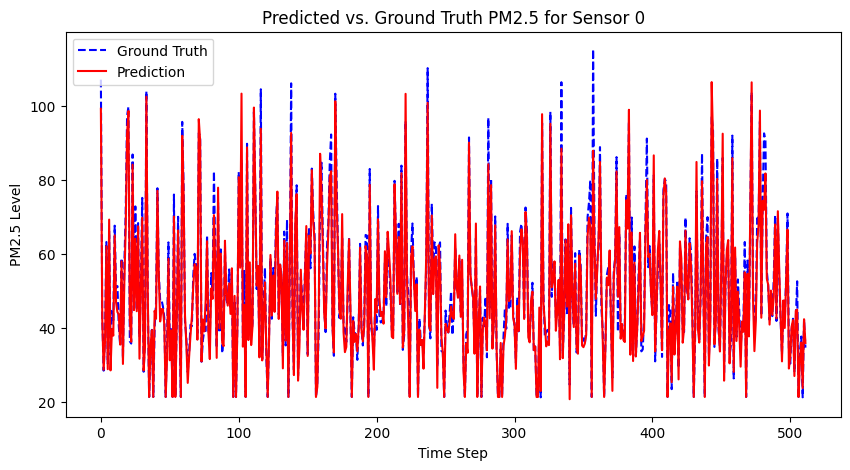

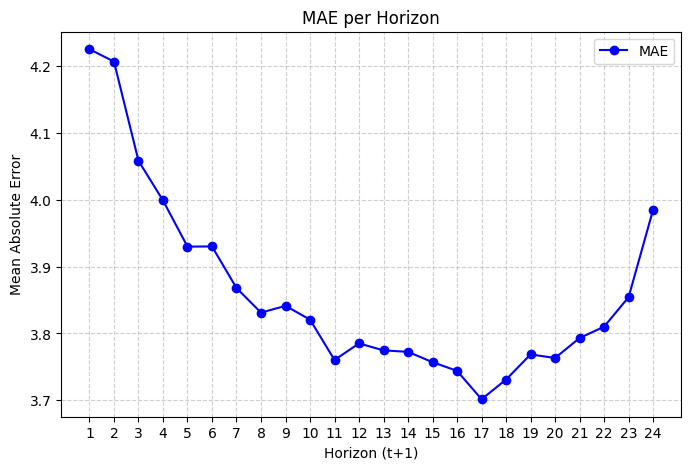

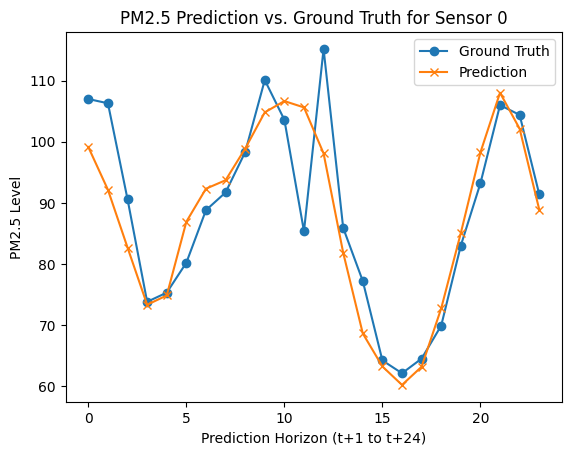

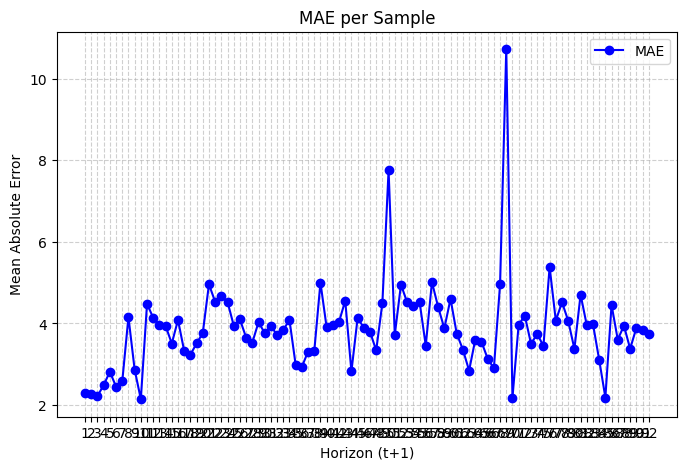

In [13]:
visualize("data/train_dcrnn_predictions.npz")

Available keys: ['prediction', 'truth']
prediction: shape (24, 128, 92)
truth: shape (24, 128, 92)


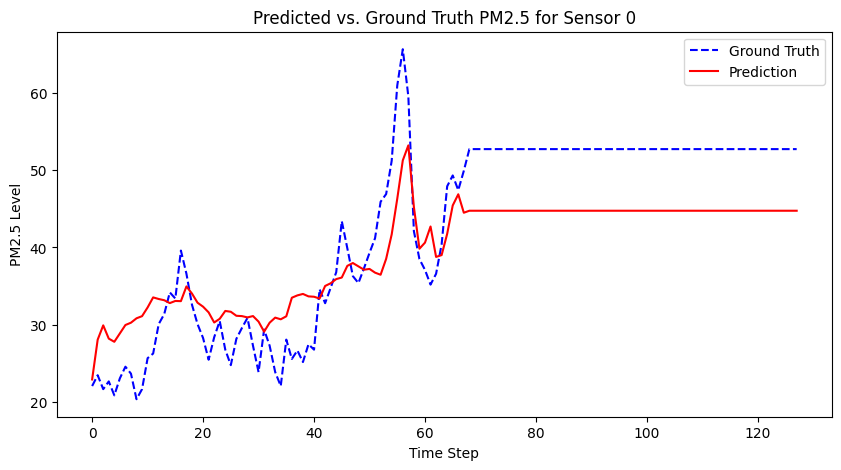

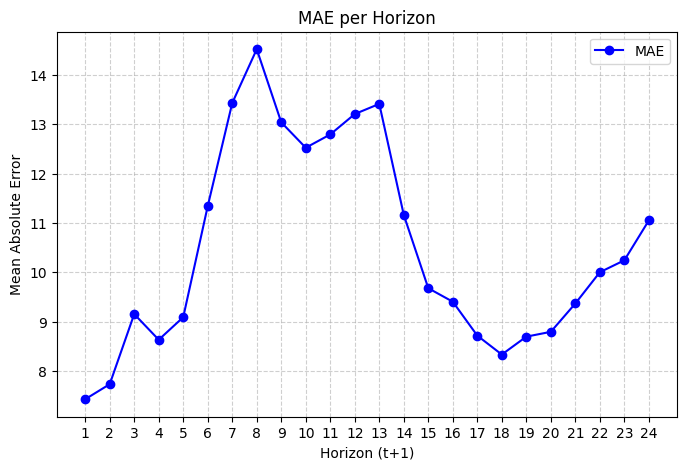

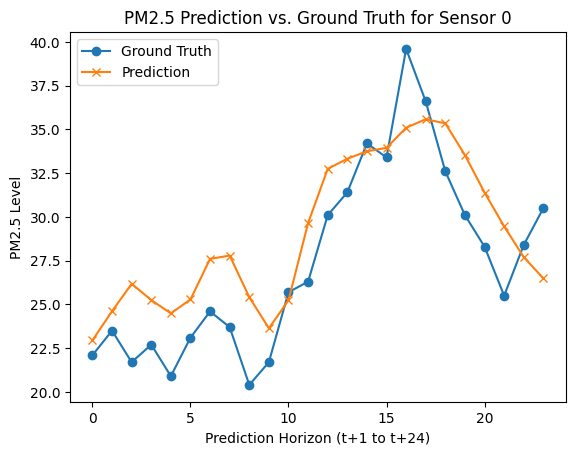

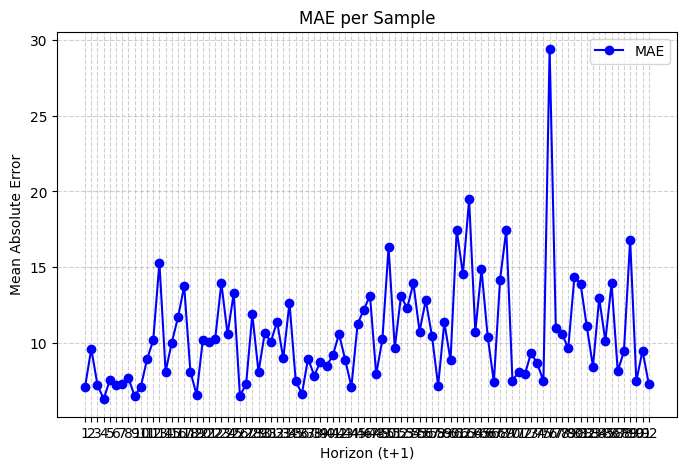

In [14]:
visualize("data/val_dcrnn_predictions.npz")

Available keys: ['prediction', 'truth']
prediction: shape (24, 192, 92)
truth: shape (24, 192, 92)


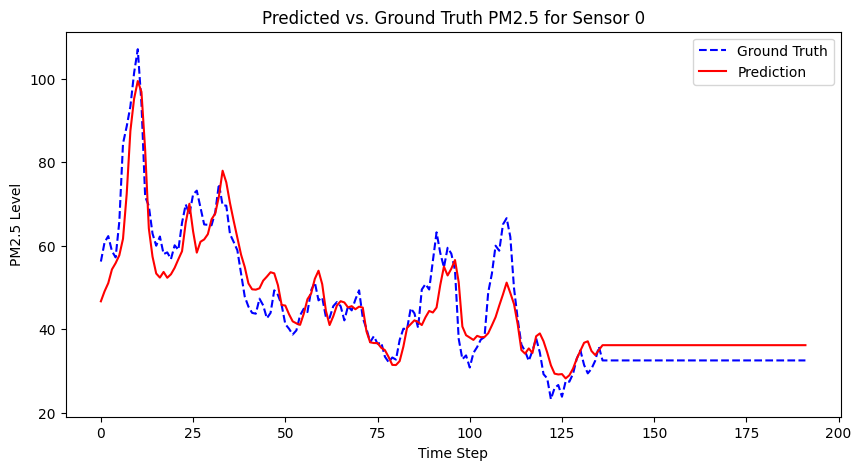

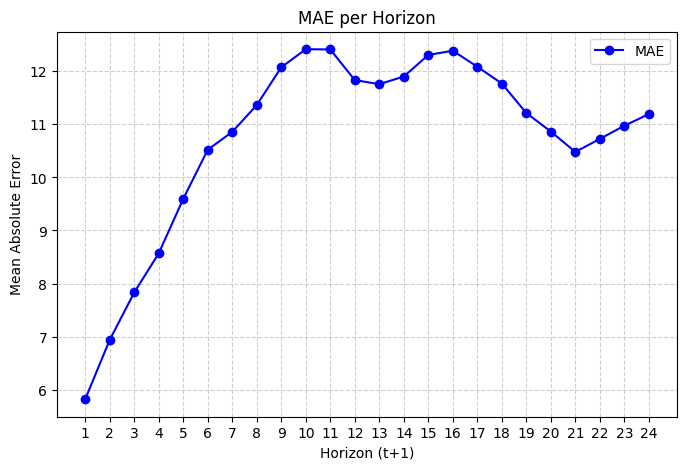

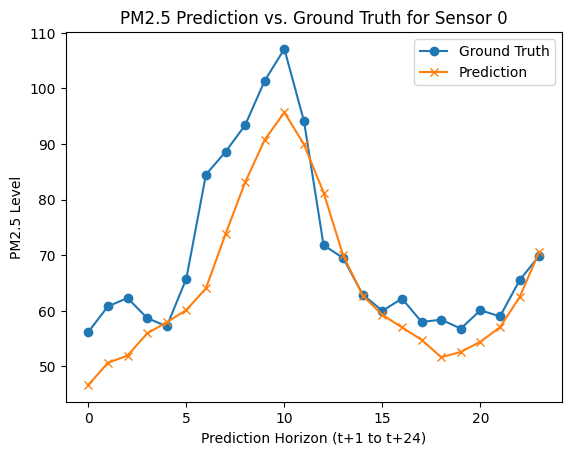

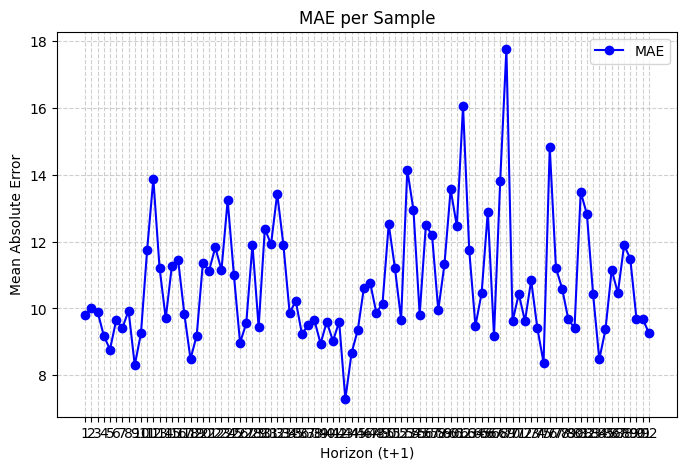

In [15]:
visualize("data/test_dcrnn_predictions.npz")

# Dimension meaning:

### Object: shape (horizon: h, num_sample: n, num_nodes: s)

- horizon: Each slice h = [0-23] correspond to the value at t+1+h tiemstep 
- num_sample: Each slice n = [0-191] correspond to the n starting position on the data
- num_nodes: Each slice s = [0-91] correspond to the 92 weather stations

### Usefully,

#### [:,i,j]: 
- gives all 24 timestep predictions where data is given to the model upto the ith timestep
- varying i shows how recursive predictions worsen over time
#### [i,:,j]: 
- gives all 192 timestep predictions where those prediction is at timestep t+1+i
- varying i shows the result at different starting points

### Expectation

- The MAE at horizon should have as little upward slope as possible with increasing timestep
- The MAE at samples should not increase much as sample goes forward as it indicates overfitting

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


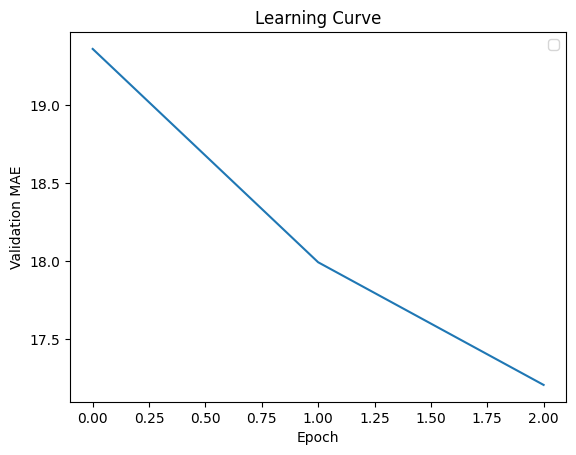

In [6]:
log_file = 'experiments/dcrnn_R_4_h_24_128-128_lr_0.001_bs_32_0304162530/info.log'

val_mae_values = []
stop_epoch = None
patience = 30

with open(log_file, 'r') as f:
    for line in f:
        if 'val_mae' in line:
            val_mae = float(line.split('val_mae: ')[1].split(',')[0])
            val_mae_values.append(val_mae)
        if 'Early stopping at epoch' in line:
            stop_epoch = int(line.split('epoch: ')[1]) - patience

plt.plot(val_mae_values)
if stop_epoch:
    plt.axvline(x=stop_epoch, color='r', linestyle='--', label='Early stopping')
plt.xlabel('Epoch')
plt.ylabel('Validation MAE')
plt.title('Learning Curve')
plt.legend()
plt.show()